Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0

# Multi-Organ Abdominal Ultrasound Segmentation with MONAI — V1: Baseline

This is **Notebook V1 (Baseline)** — the unweighted-loss version. We train a 2D UNet on multi-organ abdominal ultrasound segmentation using MONAI's standard `DiceCELoss`. The result is interesting: the model learns liver well but collapses onto a single-class solution for everything else. **The companion notebook** (`abdomen_us_v2_class_weighted.ipynb`) shows how class weights fix this.

**Target:** Liver, kidney, pancreas, spleen, gallbladder, bones, vessels, adrenals (8 organs + background = 9 classes)  
**Modality:** Abdominal Ultrasound (B-mode)  
**Task:** Multi-class 2D segmentation  
**Dataset:** [AbdomenUS on Kaggle](https://www.kaggle.com/datasets/ignaciorlando/ussimandsegm)  
**Author:** Lakshmi Mahabaleshwara

## What this tutorial covers

1. Environment detection (Kaggle / Colab / local) and dataset access
2. Config-driven design: a single `Config` dataclass drives everything downstream
3. Manifest construction: building a pandas dataframe that is the single source of truth for splits, paths, and metadata
4. Subject-grouped train/val splits (avoiding patient leakage)
5. Decoding RGB-color-coded segmentation masks into integer class maps
6. A MONAI-compatible dataset and transform pipeline
7. Training a 2D UNet with mixed-precision and a baseline loss
8. Per-class evaluation that honestly reports how the model performs on real ultrasound

## Audience and prerequisites

Written for **ML practitioners new to MONAI** and **beginners learning multi-class segmentation**. Assumes Python fluency; explains ML concepts as they come up.

## About the data

The dataset contains two domains:
- **AUS** (Artificial US): 926 synthetic scans generated by a ray-casting simulator from CT, with annotations.
- **RUS** (Real US): 617 real scans from a SonoSite M-Turbo scanner. Only 61 real scans in the test folder have annotations.

Because labeled real-ultrasound training data does not exist in this dataset, we **train and validate on AUS (synthetic)** and **report test-set performance on both AUS and the 61 annotated RUS images**.

## 1. Environment detection

**What this section does:** Detects whether the notebook is running on Kaggle, Google Colab, or a local machine, and sets up environment-specific defaults that the rest of the notebook reads from.

**Why detect the environment?** The same notebook should run unchanged in three places, but the dataset path, package installs, and worker settings differ. Detecting once and centralizing the result is cleaner than scattering `if env == "kaggle"` checks throughout the code.

### §1.1 — Detecting which platform we're on

**What this cell does:** Checks for filesystem markers (`/kaggle/input`) and import availability (`google.colab`) to figure out where we're running. Returns one of `"kaggle"`, `"colab"`, or `"local"`.

**Why this approach instead of a config flag:** Detection is unambiguous — the markers exist or they don't. A flag would require the user to set it correctly, which is one more thing that can go wrong.

In [1]:
import os
import sys
from pathlib import Path


def detect_environment() -> str:
    """Return one of 'kaggle', 'colab', 'local'."""
    if os.path.exists("/kaggle/input"):
        return "kaggle"
    try:
        import google.colab  # noqa: F401
        return "colab"
    except ImportError:
        pass
    return "local"


ENV = detect_environment()
print(f"Detected environment: {ENV}")


Detected environment: kaggle


### §1.2 — Installing dependencies

**What this cell does:** Installs MONAI (and `kagglehub` if not on Kaggle) only if they're not already available. Falls through cleanly if the environment is already set up. Also sets two environment variables to suppress harmless CUDA plugin warnings.

**Why a defensive install function?** On Kaggle, MONAI is usually pre-installed in the Docker image, so we want to skip the install. On Colab and local, we need to install it. Network failures (e.g., no internet) should produce actionable error messages, not opaque `pip` errors.

**About `TF_CPP_MIN_LOG_LEVEL` and `TF_ENABLE_ONEDNN_OPTS`:** Kaggle's Python image ships both TensorFlow and PyTorch. They each register their own cuFFT/cuDNN/cuBLAS plugins, which produces duplicate-registration warnings on import. These warnings are harmless (CUDA falls back to whichever was registered first) but visually noisy. The two env vars silence them.

**Kaggle internet note:** If you're on Kaggle and see a DNS error like "Failed to establish a new connection," your notebook doesn't have internet access enabled. Open the right-hand sidebar → "Notebook options" → toggle "Internet" ON. (Phone verification is required, free, one-time.)

In [2]:
#  Robust to three scenarios:
#   1. Already installed (Kaggle usually has MONAI pre-installed) — skip
#   2. Not installed, internet available — install
#   3. Not installed, no internet — print actionable error
import importlib
import subprocess

# Suppress harmless CUDA plugin registration warnings. These appear on Kaggle
# because both TensorFlow and PyTorch ship their own CUDA libraries and each
# tries to register the same cuFFT/cuDNN/cuBLAS plugins. The duplicate
# registration is logged as a warning but doesn't affect functionality.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"      # Hide TensorFlow info/warning logs
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"     # Silence oneDNN messages


def _ensure_package(pkg_name: str, pip_spec: str | None = None) -> bool:
    """Return True if importable. If not, try to install."""
    try:
        importlib.import_module(pkg_name)
        return True
    except ImportError:
        pass

    pip_spec = pip_spec or pkg_name
    print(f"{pkg_name} not found. Attempting install of {pip_spec}...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pip_spec],
        capture_output=True, text=True,
    )
    if result.returncode == 0:
        print(f"  Installed {pip_spec}")
        return True

    err = (result.stderr or "") + (result.stdout or "")
    if "name resolution" in err.lower() or "could not find a version" in err.lower():
        print(
            f"\n  Could not install {pip_spec}: no internet access.\n"
            f"  On Kaggle: open the right-hand sidebar -> 'Notebook options' -> "
            f"toggle 'Internet' ON.\n"
            f"  Then restart the kernel and re-run.\n"
        )
    else:
        print(f"  Install failed:\n{err[:1000]}")
    return False


_ensure_package("monai", "monai[all]")
if ENV != "kaggle":
    _ensure_package("kagglehub")

# Standard imports used throughout
import json
import random
import re
import warnings
from dataclasses import dataclass, field, asdict
from typing import Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import monai
from monai.config import print_config
from monai.data import CacheDataset, DataLoader, decollate_batch
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.transforms import (
    Compose, EnsureChannelFirstd, LoadImaged, Lambdad, MapTransform,
    RandAdjustContrastd, RandFlipd, RandGaussianNoised, Resized,
    ScaleIntensityd, Activationsd, AsDiscreted,
)
from monai.utils import set_determinism

warnings.filterwarnings("ignore", category=UserWarning)
print_config()


monai not found. Attempting install of monai[all]...
  Installed monai[all]


E0000 00:00:1777355641.409633      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777355641.458817      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777355641.888296      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777355641.888357      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777355641.888359      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777355641.888361      55 computation_placer.cc:177] computation placer already registered. Please check linka

MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cpu
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.6
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cpu
tqdm version: 4.67.3
lmdb version: 2.2.0
psutil version: 5.9.5
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: 3.11.1
pynrrd version: 1.1.3
clearml version: 2.1.6rc0

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



## 2. Config

**What this section does:** Defines every parameter the notebook uses in one place, as a `Config` dataclass.

**Why this design?** When you fork this notebook for a different dataset (or just want to tune hyperparameters), you change *one cell* instead of hunting through 20 cells. This is the "build once, reuse many" principle made concrete.

### §2.1 — Defining the config dataclass

**What this cell does:** Creates a hierarchical `Config` object with sub-configs for `data`, `model`, and `train`. Sets random seeds for reproducibility. Detects the GPU.

**Why dataclass instead of dict?** Dataclasses give you type hints, default values, and IDE autocomplete. They also fail loudly if you typo a field name (`cfg.batch_szie` raises `AttributeError` immediately, vs. `cfg["batch_szie"]` silently returning `None`).

**Why nested sub-configs?** Logical grouping. `cfg.data.image_size` and `cfg.train.batch_size` are clearly different categories of parameter. A flat config gets confusing fast.

**The `TUTORIAL_MODE` flag:** Toggles between fast verification mode (5 epochs, 30% data, ~10 min on T4) and full training (50 epochs, full data, ~75 min). Set it `True` first to verify the pipeline works end-to-end, then flip to `False` for a real run.

**`set_determinism(seed=...)`:** MONAI's helper that seeds Python's `random`, NumPy, PyTorch, and CUDA RNGs all at once. Without this, you'd get different results every run — making debugging impossible.

In [3]:
# ==== Master flag ====
TUTORIAL_MODE = False  # True = fast pass (5 epochs, 30% data); False = full training (50 epochs)


@dataclass
class DataConfig:
    """Paths and data-sampling config. Most paths are resolved at runtime."""
    data_root: Optional[Path] = None          # Resolved from ENV in §3
    aus_dir: Optional[Path] = None
    rus_dir: Optional[Path] = None
    image_size: int = 256                     # Resize target for both H and W
    val_fraction: float = 0.15                # Fraction of AUS-train subjects held out for val
    # Subset fractions used only when TUTORIAL_MODE=True:
    tutorial_train_frac: float = 0.3
    tutorial_val_frac: float = 1.0


@dataclass
class ModelConfig:
    in_channels: int = 1                      # Grayscale US
    out_channels: int = 9                     # 8 organs + background
    channels: tuple = (16, 32, 64, 128, 256)  # UNet feature counts per level
    strides: tuple = (2, 2, 2, 2)
    num_res_units: int = 2


@dataclass
class TrainConfig:
    batch_size: int = 16
    num_workers: int = 2
    learning_rate: float = 1e-4
    max_epochs: int = 5 if TUTORIAL_MODE else 50
    val_interval: int = 1
    early_stop_patience: int = 1000           # Effectively disabled; let cosine schedule run
    use_amp: bool = True
    seed: int = 42


@dataclass
class Config:
    data: DataConfig = field(default_factory=DataConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    train: TrainConfig = field(default_factory=TrainConfig)
    env: str = ENV
    tutorial_mode: bool = TUTORIAL_MODE


cfg = Config()
print(f"TUTORIAL_MODE = {cfg.tutorial_mode}")
print(f"max_epochs = {cfg.train.max_epochs}, batch_size = {cfg.train.batch_size}")
print(f"image_size = {cfg.data.image_size}")

# Determinism for reproducibility — seeds all RNGs at once
set_determinism(seed=cfg.train.seed)
random.seed(cfg.train.seed)
np.random.seed(cfg.train.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


TUTORIAL_MODE = False
max_epochs = 50, batch_size = 16
image_size = 256
Device: cpu


## 3. Dataset access

**What this section does:** Finds the dataset on disk, with three fallback strategies.

### §3.1 — Resolving the dataset path

**What this cell does:** Checks three locations in order — Kaggle mount, environment variable, conventional local path — and falls back to downloading via `kagglehub` if none exist.

**Why three fallbacks?** Different users will have the data in different places. The Kaggle mount is automatic if you've attached the dataset. The env var lets users with custom setups override paths. The local path matches a common convention. The kagglehub download is a last resort that requires Kaggle API credentials.

**Why a function returning `Path`?** Single point of truth. Every downstream cell asks `cfg.data.data_root` and gets the answer, regardless of which fallback succeeded. Adding a fourth fallback (e.g., S3) means changing one function, not 20 cells.

In [4]:
def _looks_like_data_root(path: Path) -> bool:
    """True if the path is the directory containing AUS/ and RUS/ subfolders."""
    return path.exists() and (path / "AUS").exists() and (path / "RUS").exists()


def resolve_data_root(env: str) -> Path:
    """Find the dataset root with three fallback strategies.

    Resolution order:
      1. Kaggle mount points (if running on Kaggle)
      2. ABDOMEN_US_ROOT environment variable
      3. ./data/abdominal_US/abdominal_US (common local convention)
      4. kagglehub download (requires Kaggle API credentials)
    """
    candidates: list[Path] = []

    if env == "kaggle":
        candidates += [
            Path("/kaggle/input/abdominal_US/abdominal_US"),
            Path("/kaggle/input/ussimandsegm/abdominal_US/abdominal_US"),
        ]

    env_path = os.environ.get("ABDOMEN_US_ROOT")
    if env_path:
        candidates.append(Path(env_path))

    candidates += [
        Path("./data/abdominal_US/abdominal_US"),
        Path("./abdominal_US/abdominal_US"),
    ]

    for c in candidates:
        if _looks_like_data_root(c):
            print(f"Found dataset locally at: {c}")
            return c

    print("Dataset not found locally. Attempting kagglehub download...")
    try:
        import kagglehub
    except ImportError as e:
        raise RuntimeError(
            "kagglehub not installed and dataset not found locally. "
            "Either install kagglehub, set ABDOMEN_US_ROOT to your local copy, "
            "or on Kaggle attach the dataset via 'Add Data'."
        ) from e

    downloaded = Path(kagglehub.dataset_download("ignaciorlando/ussimandsegm"))
    for inner in downloaded.rglob("abdominal_US"):
        if _looks_like_data_root(inner):
            print(f"Downloaded to: {inner}")
            return inner
    raise FileNotFoundError(f"Could not locate 'abdominal_US/' inside {downloaded}")


cfg.data.data_root = resolve_data_root(cfg.env)
cfg.data.aus_dir = cfg.data.data_root / "AUS"
cfg.data.rus_dir = cfg.data.data_root / "RUS"

print(f"Data root: {cfg.data.data_root}")

# Quick peek at the directory layout
for sub in ["AUS/images/train", "AUS/annotations/train", "AUS/images/test",
            "AUS/annotations/test", "RUS/images/test", "RUS/annotations/test"]:
    p = cfg.data.data_root / sub
    n = len(list(p.iterdir())) if p.exists() else 0
    print(f"  {sub:<30s} {n:>5d} files")


Dataset not found locally. Attempting kagglehub download...
Downloaded to: /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US
Data root: /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US
  AUS/images/train                 633 files
  AUS/annotations/train            633 files
  AUS/images/test                  293 files
  AUS/annotations/test             293 files
  RUS/images/test                  213 files
  RUS/annotations/test              61 files


## 4. Manifest construction

**What this section does:** Walks the dataset directory and builds a pandas DataFrame that's the single source of truth for every downstream decision (splits, paths, metadata).

**Why a manifest at all?** Real medical imaging projects have dozens of decisions to make about data — which subjects to use, which scans to exclude, how to handle missing labels. Encoding these decisions as code that operates on a tabular manifest is more maintainable than encoding them as hardcoded paths or scattered conditionals. The manifest is also a reproducibility artifact — saving it to disk means anyone re-running the notebook gets the same splits.

### §4.1 — Building the manifest

**What this cell does:** Walks both `AUS/` and `RUS/` directory trees, parses subject IDs from filenames using regex, and builds a DataFrame with one row per image-mask pair.

**Why regex for subject parsing?** AUS filenames look like `ct4-63.png` (subject `ct4`, frame `63`). RUS filenames look like `a42.jpg` (subject `a`). The regex captures the subject prefix, which we'll use later for subject-grouped splits.

**Why columns `image_path`, `mask_path`, `has_mask`?** Many real US images have no annotation (the RUS train set has 0 masks). Recording `has_mask=False` lets us filter by it later instead of silently dropping rows.

**Why iterate the directory once?** Disk I/O is slow on Kaggle's mounted input. Walking 2,000 files takes ~5 seconds. We do that walk once and build the manifest, then save the manifest to CSV as a reproducibility artifact (anyone re-running with the same seed gets the same splits). For this dataset's size, the walk is fast enough that we rebuild the manifest from scratch on each run rather than reading from the CSV — the CSV exists for inspection and reproducibility, not as a runtime cache. For much larger datasets (10,000+ files), you'd add `if manifest_path.exists(): return pd.read_csv(manifest_path)` at the top of `build_manifest`.

In [5]:
AUS_FILENAME_RE = re.compile(r"^(ct\d+)-\d+\.(png|jpg)$")
RUS_FILENAME_RE = re.compile(r"^([a-z]+)\d+\.(png|jpg)$", re.IGNORECASE)


def parse_subject_id(filename: str, modality: str) -> Optional[str]:
    """Extract subject id from filename. Returns None if pattern doesn't match."""
    pattern = AUS_FILENAME_RE if modality == "AUS" else RUS_FILENAME_RE
    match = pattern.match(filename)
    return match.group(1).lower() if match else None


def build_manifest(data_root: Path) -> pd.DataFrame:
    rows = []
    for modality in ["AUS", "RUS"]:
        mod_dir = data_root / modality
        for orig_split in ["train", "test"]:
            img_dir = mod_dir / "images" / orig_split
            msk_dir = mod_dir / "annotations" / orig_split
            if not img_dir.exists():
                continue
            for img_path in sorted(img_dir.iterdir()):
                if img_path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
                    continue
                subject_id = parse_subject_id(img_path.name, modality)
                mask_path = msk_dir / (img_path.stem + ".png")
                rows.append({
                    "subject_id": subject_id,
                    "modality": modality,
                    "orig_split": orig_split,
                    "image_path": str(img_path),
                    "mask_path": str(mask_path) if mask_path.exists() else None,
                    "has_mask": mask_path.exists(),
                })
    return pd.DataFrame(rows)


manifest = build_manifest(cfg.data.data_root)
print(f"Total rows: {len(manifest)}")
print("\nCounts by modality x orig_split x has_mask:")
print(manifest.groupby(["modality", "orig_split", "has_mask"]).size().unstack(fill_value=0))
print("\nSubjects per (modality, orig_split):")
print(manifest.groupby(["modality", "orig_split"])["subject_id"].nunique())


Total rows: 1543

Counts by modality x orig_split x has_mask:
has_mask             False  True 
modality orig_split              
AUS      test            0    293
         train           0    633
RUS      test          153     60
         train         404      0

Subjects per (modality, orig_split):
modality  orig_split
AUS       test          4
          train         9
RUS       test          4
          train         7
Name: subject_id, dtype: int64


### §4.2 — Inspecting the manifest

**What this cell does:** Prints sample rows from each modality and flags any rows where subject ID parsing failed.

**Why print samples?** Sanity check. If your regex is wrong, this is where you'd notice — sample rows would show `subject_id=None` or unexpected values. Catching it here saves debugging confusion later.

In [6]:
print("AUS sample:")
print(manifest[manifest["modality"] == "AUS"].head(3).to_string(index=False))
print("\nRUS sample:")
print(manifest[manifest["modality"] == "RUS"].head(3).to_string(index=False))

unparsed = manifest[manifest["subject_id"].isna()]
print(f"\nRows with unparsable subject_id: {len(unparsed)}")


AUS sample:
subject_id modality orig_split                                                                                               image_path                                                                                                     mask_path  has_mask
      ct14      AUS      train  /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/images/train/ct14-1.png  /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/annotations/train/ct14-1.png      True
      ct14      AUS      train /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/images/train/ct14-10.png /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/annotations/train/ct14-10.png      True
      ct14      AUS      train /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/images/train/ct14-11.png /kaggle/input/datasets/ignaciorlando/ussimandsegm/abdominal_US/abdominal_US/AUS/anno

## 5. Subject-grouped splits

**What this section does:** Assigns each manifest row to one of `train`, `val`, `test_aus`, `test_rus`, ensuring no subject's frames appear in multiple splits.

**Why subject-grouped splits matter (the most important rule in medical ML):** If you split frames randomly, frames from the same patient end up in both train and test. The model "memorizes" patient-specific features and reports inflated test scores that don't generalize to new patients. This is *subject leakage*, and it's the #1 source of overstated results in medical imaging papers. Always split by subject.

### §5.1 — Assigning splits

**What this cell does:** Uses sklearn's `GroupShuffleSplit` with `groups=subject_id` to ensure no AUS subject appears in both train and val. Test splits are taken directly from the dataset's pre-shipped train/test directories.

**Why the assertion at the end?** Defensive programming. If our split logic ever broke (e.g., regex change, refactor), the assertion would crash loudly with a clear error message instead of silently producing leaky splits.

**The four splits:**
- `train`: AUS train minus held-out subjects (what we train on)
- `val`: AUS train held-out subjects (what we tune on)
- `test_aus`: AUS test (in-distribution test — how well did we learn the synthetic task?)
- `test_rus`: RUS test with masks (out-of-distribution test — how does it transfer to real ultrasound?)

In [7]:
from sklearn.model_selection import GroupShuffleSplit


def assign_splits(manifest: pd.DataFrame, val_fraction: float, seed: int) -> pd.DataFrame:
    manifest = manifest.copy()
    manifest["split"] = None

    rus_test_mask = (manifest["modality"] == "RUS") & \
                    (manifest["orig_split"] == "test") & \
                    (manifest["has_mask"])
    manifest.loc[rus_test_mask, "split"] = "test_rus"

    aus_test_mask = (manifest["modality"] == "AUS") & (manifest["orig_split"] == "test")
    manifest.loc[aus_test_mask, "split"] = "test_aus"

    aus_train = manifest[(manifest["modality"] == "AUS") & (manifest["orig_split"] == "train")]
    groups = aus_train["subject_id"].values

    gss = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    train_idx, val_idx = next(gss.split(X=aus_train, y=None, groups=groups))
    train_subjects = set(aus_train.iloc[train_idx]["subject_id"].unique())
    val_subjects = set(aus_train.iloc[val_idx]["subject_id"].unique())

    manifest.loc[aus_train.index[aus_train["subject_id"].isin(train_subjects)],
                 "split"] = "train"
    manifest.loc[aus_train.index[aus_train["subject_id"].isin(val_subjects)],
                 "split"] = "val"

    # Subject-leakage assertion: catches bugs that would invalidate results
    assert train_subjects.isdisjoint(val_subjects), "Subject leak between train and val!"
    return manifest


manifest = assign_splits(manifest, cfg.data.val_fraction, cfg.train.seed)

print("Split sizes:")
print(manifest["split"].value_counts(dropna=False))
print("\nSubjects per split (non-null splits):")
print(manifest.dropna(subset=["split"]).groupby("split")["subject_id"].nunique())

manifest_path = Path("/kaggle/working/manifest.csv") if cfg.env == "kaggle" else Path("manifest.csv")
manifest.to_csv(manifest_path, index=False)
print(f"\nManifest saved: {manifest_path}")


Split sizes:
split
None        557
train       511
test_aus    293
val         122
test_rus     60
Name: count, dtype: int64

Subjects per split (non-null splits):
split
test_aus    4
test_rus    4
train       7
val         2
Name: subject_id, dtype: int64

Manifest saved: /kaggle/working/manifest.csv


### §5.2 — Optional subset for tutorial mode

**What this cell does:** When `TUTORIAL_MODE=True`, downsamples the train split to 30% to keep epochs short. Val and test are left intact so metrics stay meaningful.

**Why subset only the train set?** Faster epochs without sacrificing the quality of validation/test metrics. You want to know how well the model performs on the full evaluation sets even when training is cheap.

In [8]:
if cfg.tutorial_mode:
    train_rows = manifest[manifest["split"] == "train"]
    n_keep = max(1, int(len(train_rows) * cfg.data.tutorial_train_frac))
    train_keep = train_rows.sample(n=n_keep, random_state=cfg.train.seed).index
    train_drop = train_rows.index.difference(train_keep)
    manifest.loc[train_drop, "split"] = None

    print(f"TUTORIAL_MODE: kept {n_keep}/{len(train_rows)} training frames.")
    print("Split sizes (after subsetting):")
    print(manifest["split"].value_counts(dropna=False))


## 6. Mask decoding — the feature engineering cell

**What this section does:** Converts RGB color masks into integer class index maps that PyTorch can train on.

**Why this is necessary:** The dataset ships masks as PNG images where colors encode meaning (violet = liver, yellow = kidney). PyTorch's loss functions expect integer class indices (0, 1, 2, ...), not RGB triplets. We need to convert.

**Color palette:**

| Color | RGB | Class |
|---|---|---|
| Black | (0, 0, 0) | 0 — background |
| Violet | (100, 0, 100) | 1 — liver |
| White | (255, 255, 255) | 2 — bone |
| Green | (0, 255, 0) | 3 — gallbladder |
| Yellow | (255, 255, 0) | 4 — kidney |
| Blue | (0, 0, 255) | 5 — pancreas |
| Red | (255, 0, 0) | 6 — vessels |
| Magenta | (255, 0, 255) | 7 — spleen |
| Cyan | (0, 255, 255) | 8 — adrenal |

### §6.1 — RGB-to-class-index converter

**What this cell does:** Defines `rgb_mask_to_class_map`, which converts an `(H, W, 3)` RGB mask into an `(H, W)` class index map.

**Why nearest-neighbor matching instead of exact equality?** PNG masks should have exact colors, but resize interpolation can introduce off-palette intermediate values at boundaries. Using Euclidean distance to the nearest palette color makes the decoder robust to these tiny perturbations. The alternative (exact match) would silently mislabel boundary pixels as "background."

**The `int32` cast** is critical: squared RGB differences can exceed int16 range (max squared distance ≈ 195,000, int16 max = 32,767). An earlier version of this notebook used int16 and silently produced wrong class assignments due to integer overflow — a subtle bug that wouldn't crash but would corrupt training. 

In [10]:
CLASS_PALETTE = [
    ((0,   0,   0),   "background"),
    ((100, 0,   100), "liver"),
    ((255, 255, 255), "bone"),
    ((0,   255, 0),   "gallbladder"),
    ((255, 255, 0),   "kidney"),
    ((0,   0,   255), "pancreas"),
    ((255, 0,   0),   "vessels"),
    ((255, 0,   255), "spleen"),
    ((0,   255, 255), "adrenal"),
]
NUM_CLASSES = len(CLASS_PALETTE)
CLASS_NAMES = [name for _, name in CLASS_PALETTE]
PALETTE_ARR = np.array([rgb for rgb, _ in CLASS_PALETTE], dtype=np.int32)


def rgb_mask_to_class_map(mask_rgb: np.ndarray) -> np.ndarray:
    """Convert an (H, W, 3) uint8 RGB mask into an (H, W) uint8 class index map.

    Uses nearest-neighbor matching against the palette. int32 dtype is
    required because squared uint8 differences can exceed int16 range.
    """
    if mask_rgb.ndim == 2:
        return mask_rgb.astype(np.uint8)
    if mask_rgb.shape[-1] == 4:
        mask_rgb = mask_rgb[..., :3]
    h, w = mask_rgb.shape[:2]
    flat = mask_rgb.reshape(-1, 3).astype(np.int32)
    d2 = ((flat[:, None, :] - PALETTE_ARR[None, :, :]) ** 2).sum(-1)
    classes = d2.argmin(axis=1).astype(np.uint8)
    return classes.reshape(h, w)


### §6.2 — Visualizing one mask decoding

**What this cell does:** Picks a training sample, shows the original ultrasound, the RGB mask, and the decoded class map side by side.

**Why this matters:** Sanity check that the decoder works. If the class map looks like noise or doesn't match the RGB mask's structure, something is wrong with the decoder.

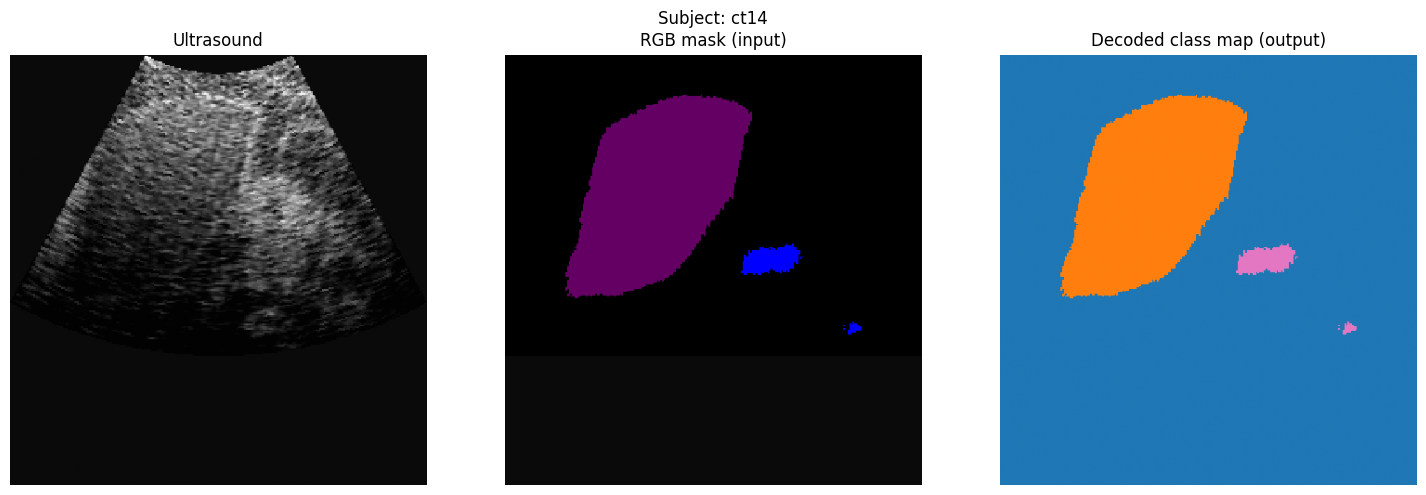


Pixel counts by class: {'background': 177967, 'liver': 28751, 'pancreas': 1618}


In [11]:
sample_row = manifest[manifest["split"] == "train"].iloc[0]
img = np.array(Image.open(sample_row["image_path"]).convert("L"))
mask_rgb = np.array(Image.open(sample_row["mask_path"]).convert("RGB"))
class_map = rgb_mask_to_class_map(mask_rgb)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap="gray");      axes[0].set_title("Ultrasound"); axes[0].axis("off")
axes[1].imshow(mask_rgb);              axes[1].set_title("RGB mask (input)"); axes[1].axis("off")
axes[2].imshow(class_map, cmap="tab10", vmin=0, vmax=NUM_CLASSES-1)
axes[2].set_title("Decoded class map (output)"); axes[2].axis("off")
plt.suptitle(f"Subject: {sample_row['subject_id']}")
plt.tight_layout(); plt.show()

unique, counts = np.unique(class_map, return_counts=True)
present = {CLASS_NAMES[c]: int(n) for c, n in zip(unique, counts)}
print(f"\nPixel counts by class: {present}")


## 7. MONAI transforms and CacheDataset

**What this section does:** Wraps the mask decoder in a MONAI transform, defines train/val transform pipelines, and builds `CacheDataset` instances that preprocess once and cache in RAM.

**Why MONAI's dictionary transforms?** They guarantee that image and mask transformations stay in sync. When `RandFlipd` flips, it flips both; when `Resized` resizes, it resizes both consistently. Doing this manually is error-prone — it's a common source of silent training bugs.

### §7.1 — Custom transform: decoding RGB masks in the pipeline

**What this cell does:** Wraps the `rgb_mask_to_class_map` function in a MONAI `MapTransform` so it integrates with the dictionary pipeline.

**Why a custom MapTransform instead of preprocessing masks ahead of time?** Two reasons. First, this keeps preprocessing colocated with training — no separate "preprocess masks" script that needs to stay in sync. Second, MONAI's `CacheDataset` will run this once per sample on first epoch and cache the output, so we pay no per-epoch cost.

In [13]:
class DecodeRGBMaskd(MapTransform):
    """Decode an RGB mask into a class index map in a MONAI dict pipeline.

    Expects the mask to arrive as (3, H, W) or (H, W, 3) uint8. Outputs
    (1, H, W) int64 class indices.
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            arr = d[key]
            if hasattr(arr, "numpy"):
                arr = arr.numpy()
            arr = np.asarray(arr)
            if arr.ndim == 3 and arr.shape[0] in (3, 4):
                arr = np.transpose(arr, (1, 2, 0))
            elif arr.ndim == 3 and arr.shape[0] == 1:
                d[key] = arr.astype(np.int64)
                continue
            elif arr.ndim == 2:
                d[key] = arr[None, ...].astype(np.int64)
                continue
            class_map = rgb_mask_to_class_map(arr.astype(np.uint8))
            d[key] = class_map[None, ...].astype(np.int64)
        return d


### §7.2 — Building the transform pipelines

**What this cell does:** Defines two `Compose` pipelines — one for training (with augmentation) and one for validation (deterministic).

**Why these specific augmentations:**

- **`RandFlipd` horizontal only.** Abdominal ultrasound has anatomical laterality (liver right, spleen left). Vertical flip would create unphysical images that confuse the model.
- **`RandGaussianNoised` with small sigma (0.02).** Ultrasound is already noisy; heavy noise augmentation hurts more than helps. Light noise teaches the model to ignore speckle.
- **`RandAdjustContrastd`.** Real ultrasound gain settings vary by operator. This augmentation simulates that variation.
- **No rotation.** Ultrasound images are oriented by convention (probe at top, depth increasing downward). Rotating them is unphysical.

**Why no augmentation for validation?** We want validation metrics to be deterministic and comparable across epochs. Random augmentation would add noise to the metric.

In [16]:
def build_transforms(image_size: int, training: bool) -> Compose:
    base = [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        # If image loaded as RGB, collapse to grayscale by averaging channels
        Lambdad(keys="image",
                func=lambda x: x.mean(dim=0, keepdim=True) if x.shape[0] == 3 else x),
        DecodeRGBMaskd(keys=["label"]),
        Resized(keys=["image"], spatial_size=(image_size, image_size), mode="bilinear"),
        Resized(keys=["label"], spatial_size=(image_size, image_size), mode="nearest"),
        ScaleIntensityd(keys="image", minv=0.0, maxv=1.0),
    ]
    if training:
        base += [
            RandFlipd(keys=["image", "label"], spatial_axis=1, prob=0.5),
            RandGaussianNoised(keys="image", prob=0.3, mean=0.0, std=0.02),
            RandAdjustContrastd(keys="image", prob=0.3, gamma=(0.8, 1.2)),
        ]
    return Compose(base)


train_transforms = build_transforms(cfg.data.image_size, training=True)
val_transforms = build_transforms(cfg.data.image_size, training=False)


### §7.3 — CacheDataset and DataLoader

**What this cell does:** Converts manifest rows into MONAI's expected list-of-dicts format, then wraps them in `CacheDataset` for fast repeated access.

**Why CacheDataset instead of plain Dataset?** Preprocessing (load + decode + resize) takes ~20ms per sample. Across 50 epochs and ~500 training samples, that's 8 minutes of pure preprocessing. `CacheDataset` runs preprocessing once at startup, caches results in RAM, and replays them every epoch — preprocessing time becomes effectively zero.

**Why not `PersistentDataset` (disk cache)?** The dataset fits in T4 RAM after preprocessing (~1 GB). RAM is faster than disk and we don't need cache survival across kernel restarts for a tutorial.

**Why `cache_num=min(len, 500)`?** Caps the cache to the first 500 samples in case the dataset is huge. For our scale, this is `len(train_files)`.

In [17]:
def rows_to_monai_dicts(rows: pd.DataFrame) -> list[dict]:
    return [
        {"image": r["image_path"], "label": r["mask_path"]}
        for _, r in rows.iterrows()
        if r["mask_path"] is not None
    ]


train_files    = rows_to_monai_dicts(manifest[manifest["split"] == "train"])
val_files      = rows_to_monai_dicts(manifest[manifest["split"] == "val"])
test_aus_files = rows_to_monai_dicts(manifest[manifest["split"] == "test_aus"])
test_rus_files = rows_to_monai_dicts(manifest[manifest["split"] == "test_rus"])

print(f"train: {len(train_files)}  val: {len(val_files)}  "
      f"test_aus: {len(test_aus_files)}  test_rus: {len(test_rus_files)}")

cache_num_train = min(len(train_files), 500)
cache_num_val = min(len(val_files), 200)

train_ds = CacheDataset(data=train_files, transform=train_transforms,
                        cache_num=cache_num_train, num_workers=cfg.train.num_workers)
val_ds = CacheDataset(data=val_files, transform=val_transforms,
                      cache_num=cache_num_val, num_workers=cfg.train.num_workers)

train_loader = DataLoader(train_ds, batch_size=cfg.train.batch_size, shuffle=True,
                          num_workers=cfg.train.num_workers,
                          pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False,
                        num_workers=cfg.train.num_workers,
                        pin_memory=(device.type == "cuda"))

print(f"Cached {cache_num_train} train samples and {cache_num_val} val samples.")


train: 511  val: 122  test_aus: 293  test_rus: 60


Loading dataset: 100%|██████████| 122/122 [00:07<00:00, 16.37it/s]

Cached 500 train samples and 122 val samples.


### §7.4 — Sanity-check a training batch

**What this cell does:** Pulls one batch from `train_loader`, prints its shapes, and visualizes the augmented images alongside their masks.

**Why this is critical:** Confirms three things at once: (a) the data loading pipeline produces tensors of the expected shape, (b) augmentations are being applied (you'll see horizontal flips), and (c) image-mask pairs stay aligned through augmentation.

**What to look for:** All 9 unique class indices present (0–8), image values in roughly [0, 1] range, image and mask shapes both `(B, 1, 256, 256)`.

Image batch: shape=(16, 1, 256, 256), dtype=torch.float32, range=[-0.06, 1.04]
Label batch: shape=(16, 1, 256, 256), dtype=torch.float32, unique classes=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]


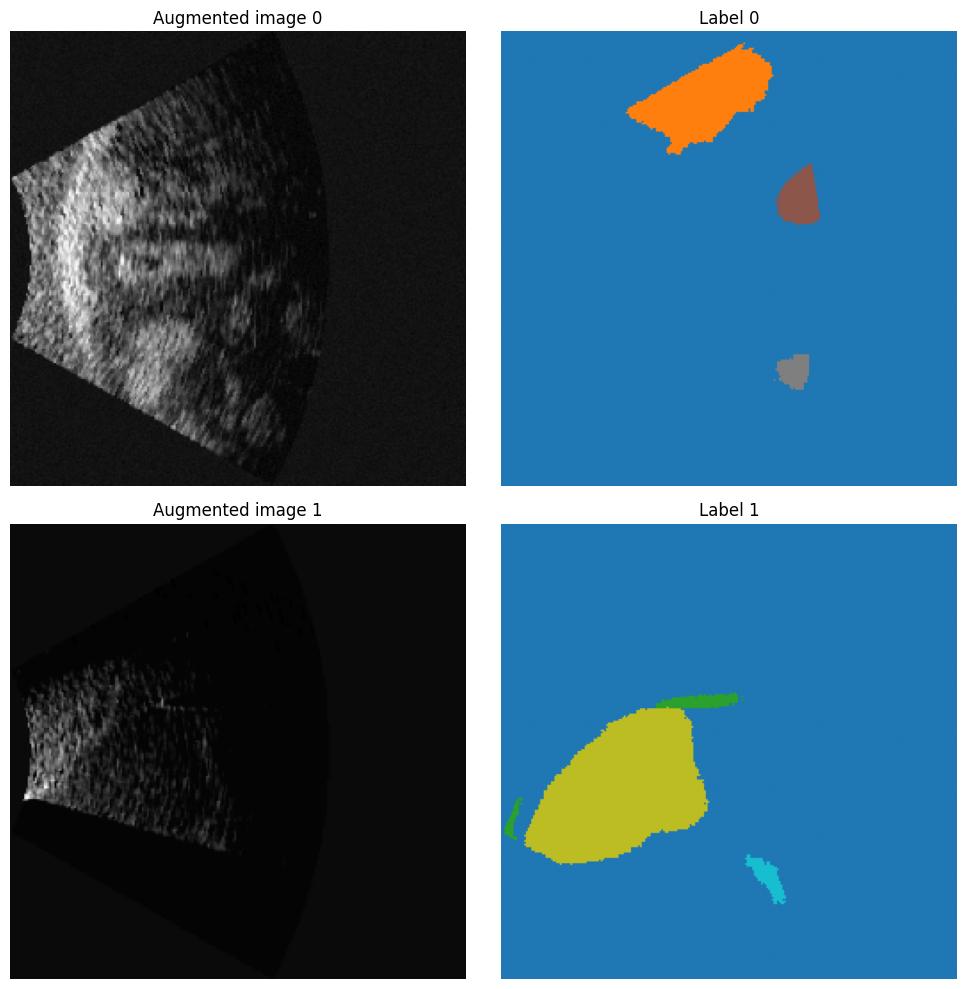

In [18]:
batch = next(iter(train_loader))
img_batch = batch["image"]
lbl_batch = batch["label"]
print(f"Image batch: shape={tuple(img_batch.shape)}, dtype={img_batch.dtype}, "
      f"range=[{img_batch.min():.2f}, {img_batch.max():.2f}]")
print(f"Label batch: shape={tuple(lbl_batch.shape)}, dtype={lbl_batch.dtype}, "
      f"unique classes={sorted(torch.unique(lbl_batch).tolist())}")

n_show = min(2, img_batch.shape[0])
fig, axes = plt.subplots(n_show, 2, figsize=(10, 5 * n_show))
if n_show == 1:
    axes = axes[None, :]
for i in range(n_show):
    axes[i, 0].imshow(img_batch[i, 0].cpu(), cmap="gray")
    axes[i, 0].set_title(f"Augmented image {i}"); axes[i, 0].axis("off")
    axes[i, 1].imshow(lbl_batch[i, 0].cpu(), cmap="tab10", vmin=0, vmax=NUM_CLASSES-1)
    axes[i, 1].set_title(f"Label {i}"); axes[i, 1].axis("off")
plt.tight_layout(); plt.show()


## 8. Model, loss, optimizer — the heart of the training setup

**What this section does:** Defines the three pieces that make training possible: the neural network, the loss function, and the optimizer.

### §8.1 The model — MONAI's 2D UNet

**What this is:** A 2D U-shaped convolutional network with skip connections, the reference architecture for medical image segmentation.

**The U shape:**
- **Encoder (down-path):** progressively reduces spatial resolution (256 → 128 → 64 → 32 → 16) while increasing feature channels (16 → 32 → 64 → 128 → 256). Each step captures more abstract, larger-context features.
- **Decoder (up-path):** progressively restores spatial resolution back to 256×256, producing one prediction per pixel.
- **Skip connections (the trick):** at each level, encoder features are concatenated with decoder features. Combines "where" (high-res) with "what" (abstract).

**Our specific settings:**
- `channels=(16, 32, 64, 128, 256)` — feature counts at each level. Doubling is standard.
- `strides=(2, 2, 2, 2)` — downsample by 2× at each transition.
- `num_res_units=2` — residual blocks for better gradient flow.
- `in_channels=1, out_channels=9` — grayscale input, 9-class output (background + 8 organs).

This gives ~2M parameters.

### §8.2 The loss — `DiceCELoss` (V1: no class weights)

**What this is:** A combined loss adding two terms: Dice loss (region overlap) + Cross-Entropy loss (per-pixel classification).

**Why combine them?**
- Dice loss alone is unstable early in training (gradients explode when predictions are mostly empty).
- Cross-entropy alone encourages the model to predict "everything is background" and achieve 95% pixel accuracy without learning anything useful.
- Together: cross-entropy provides stable early learning; Dice pushes toward good overlap as predictions mature.

**V1 caveat — what you'll see:** Without class weights, this loss treats all classes equally. Because liver is the largest and most common organ, the model's gradient signal is dominated by liver pixels. The model converges to a local optimum of "predict liver wherever there's organ-like signal" — a phenomenon called **mode collapse**. You'll see this clearly in §10's per-class Dice: liver will be the only class with meaningful Dice.

This is intentional — V1 is the educational baseline that makes the V2 fix (class weights) tangible. See [V2 notebook](./abdomen_us_v2_class_weighted.ipynb) for the fix.

**Loss arguments:**
- `to_onehot_y=True` — labels arrive as integer class maps; loss converts to one-hot internally.
- `softmax=True` — apply softmax inside the loss for numerical stability.
- `include_background=True` — include background in the loss so the model learns to predict it.

In [19]:
model = UNet(
    spatial_dims=2,
    in_channels=cfg.model.in_channels,
    out_channels=cfg.model.out_channels,
    channels=cfg.model.channels,
    strides=cfg.model.strides,
    num_res_units=cfg.model.num_res_units,
    norm="batch",
).to(device)

# V1: no class weights. We'll see mode collapse onto liver in §10.
loss_fn = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    include_background=True,
)

optimizer = torch.optim.Adam(model.parameters(), lr=cfg.train.learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.max_epochs)

dice_metric = DiceMetric(include_background=False, reduction="mean_batch")

post_pred = Compose([Activationsd(keys="pred", softmax=True),
                     AsDiscreted(keys="pred", argmax=True, to_onehot=cfg.model.out_channels)])
post_label = Compose([AsDiscreted(keys="label", to_onehot=cfg.model.out_channels)])

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: MONAI 2D UNet ({n_params:,} parameters)")
print(f"Loss: DiceCELoss (V1: no class weights)")


Model: MONAI 2D UNet (1,630,334 parameters)
Loss: DiceCELoss (V1: no class weights)


### §8.3 The optimizer — Adam + Cosine annealing

**Adam** is an adaptive learning-rate optimizer. It maintains separate effective learning rates per parameter based on recent gradient statistics. Robust default for medical imaging because it handles noisy gradients gracefully.

**Cosine annealing scheduler** smoothly decreases the learning rate from `1e-4` at epoch 1 to near-zero at the final epoch, following a half-cosine curve. Higher LR early helps exploration; lower LR late helps convergence to a precise minimum.

### §8.4 The metric — `DiceMetric` (different from Dice loss!)

**Important distinction:**
- The Dice *inside the loss* operates on continuous probabilities (post-softmax) for differentiability.
- The Dice *as an evaluation metric* operates on discrete class predictions (post-argmax) — what humans interpret as "segmentation quality."

These produce different numbers. The metric is what we report.

**`include_background=False`:** background is ~95% of pixels and trivial to get right. Including it in the mean inflates scores and hides real failure modes on the actual organs.

## 9. Training loop

**What this section does:** Runs the standard PyTorch training loop with mixed precision, periodic validation, checkpointing on best validation Dice, and per-epoch metric logging to a CSV.

### §9.1 — The training loop

**What this cell does:** For each epoch, trains over the train loader, validates over the val loader, logs metrics, saves checkpoints when val Dice improves.

**Why mixed precision (`torch.amp`)?** On a T4, mixed precision roughly halves training time. PyTorch wraps the forward pass in `autocast("cuda")` (using fp16 where safe) and uses `GradScaler("cuda")` to keep loss-scaling numerically stable.

**Why log metrics to a DataFrame saved to CSV every epoch?** If the kernel dies mid-training, you don't lose the run history. Loose Python lists would be lost on a kernel restart; a CSV survives.

**The `*` in epoch output** marks epochs where validation Dice improved and the checkpoint was saved. Useful for skimming the log to see when the model peaked.

**Why early stopping is effectively disabled (`patience=1000`):** Validation Dice is noisy due to the small val set, so early stopping fires too aggressively. Letting cosine schedule run to completion is more reliable.

In [20]:
from torch.amp import autocast, GradScaler

history = []
best_mean_dice = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_model_path = (Path("/kaggle/working") if cfg.env == "kaggle" else Path(".")) / "best_model.pth"
history_path = (Path("/kaggle/working") if cfg.env == "kaggle" else Path(".")) / "train_history.csv"

scaler = GradScaler("cuda", enabled=cfg.train.use_amp and device.type == "cuda")

for epoch in range(1, cfg.train.max_epochs + 1):
    model.train()
    running_loss, steps = 0.0, 0
    for batch in train_loader:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast("cuda", enabled=scaler.is_enabled()):
            logits = model(images)
            loss = loss_fn(logits, labels)
        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        steps += 1
    scheduler.step()
    train_loss = running_loss / max(1, steps)

    model.eval()
    dice_metric.reset()
    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)
            with autocast("cuda", enabled=scaler.is_enabled()):
                logits = model(images)
            preds = [post_pred({"pred": p})["pred"] for p in decollate_batch(logits)]
            gts   = [post_label({"label": l})["label"] for l in decollate_batch(labels)]
            dice_metric(y_pred=preds, y=gts)

    per_class = dice_metric.aggregate().cpu().numpy()
    mean_dice = float(np.nanmean(per_class))

    row = {"epoch": epoch, "train_loss": train_loss, "mean_dice": mean_dice}
    for cls_idx, dice in enumerate(per_class, start=1):
        row[f"dice_{CLASS_NAMES[cls_idx]}"] = float(dice)
    history.append(row)
    pd.DataFrame(history).to_csv(history_path, index=False)

    improved = mean_dice > best_mean_dice + 1e-4
    if improved:
        best_mean_dice = mean_dice
        best_epoch = epoch
        torch.save(model.state_dict(), best_model_path)
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    star = " *" if improved else ""
    print(f"Epoch {epoch:3d}/{cfg.train.max_epochs} | "
          f"loss={train_loss:.4f} | mean_dice={mean_dice:.4f}{star}")

    if epochs_without_improvement >= cfg.train.early_stop_patience:
        print(f"Early stopping: no improvement in {cfg.train.early_stop_patience} epochs.")
        break

print(f"\nBest mean Dice = {best_mean_dice:.4f} at epoch {best_epoch}")
print(f"Best model: {best_model_path}")


Epoch   1/50 | loss=3.1209 | mean_dice=0.0462 *
Epoch   2/50 | loss=2.8227 | mean_dice=0.0716 *
Epoch   3/50 | loss=2.5788 | mean_dice=0.0832 *
Epoch   4/50 | loss=2.3752 | mean_dice=0.0766
Epoch   5/50 | loss=2.1952 | mean_dice=0.0755
Epoch   6/50 | loss=2.0444 | mean_dice=0.0803
Epoch   7/50 | loss=1.9054 | mean_dice=0.0758
Epoch   8/50 | loss=1.8018 | mean_dice=0.0646
Epoch   9/50 | loss=1.6988 | mean_dice=0.0712
Epoch  10/50 | loss=1.6220 | mean_dice=0.0772
Epoch  11/50 | loss=1.5540 | mean_dice=0.0680
Epoch  12/50 | loss=1.4885 | mean_dice=0.0812
Epoch  13/50 | loss=1.4439 | mean_dice=0.0712
Epoch  14/50 | loss=1.4120 | mean_dice=0.0786
Epoch  15/50 | loss=1.3773 | mean_dice=0.0813
Epoch  16/50 | loss=1.3534 | mean_dice=0.0813
Epoch  17/50 | loss=1.3167 | mean_dice=0.0796
Epoch  18/50 | loss=1.2919 | mean_dice=0.0805
Epoch  19/50 | loss=1.2838 | mean_dice=0.0781
Epoch  20/50 | loss=1.2637 | mean_dice=0.0774
Epoch  21/50 | loss=1.2437 | mean_dice=0.0756
Epoch  22/50 | loss=1.2352 |

### §9.2 — Training curves

**What this cell does:** Plots training loss and validation Dice over epochs.

**What to look for:**
- Training loss should decrease smoothly. Noisy spikes can indicate too-high learning rate or batch-size issues.
- Validation Dice should generally trend upward, even if noisy. A flat or decreasing val Dice while train loss drops is the signature of overfitting.

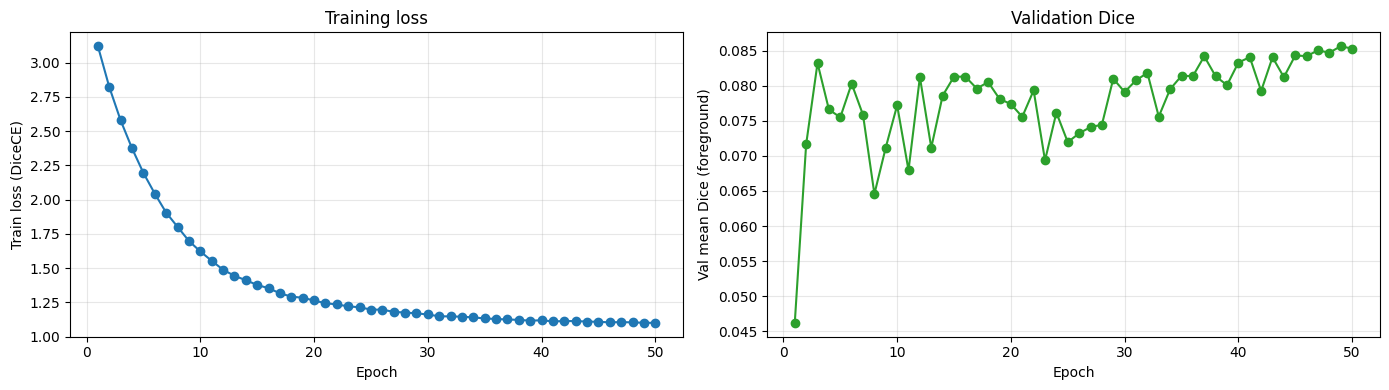

In [28]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss (DiceCE)")
axes[0].set_title("Training loss"); axes[0].grid(alpha=0.3)

axes[1].plot(hist_df["epoch"], hist_df["mean_dice"], marker="o", color="tab:green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val mean Dice (foreground)")
axes[1].set_title("Validation Dice"); axes[1].grid(alpha=0.3)
plt.tight_layout(); 
plt.savefig("/kaggle/working/v1_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()


## 10. Evaluation

**What this section does:** Loads the best checkpoint, evaluates it on both AUS test (synthetic, in-distribution) and RUS test (real, out-of-distribution), reports per-class Dice.

**Why two test sets?** AUS test tells us how well the model learned the task. RUS test tells us how well the model transfers to real ultrasound, the only thing that matters clinically. Reporting both is valid; reporting only AUS would be misleading.

### §10.1 — Per-sample evaluation

**What this cell does:** Defines `evaluate(files, label)` that runs the best model over a set of files and returns per-sample per-class Dice scores.

**Why per-sample, not just mean?** The mean averages everything together; per-sample lets us see distributions (boxplots, outliers) and stratify by metadata if needed. We use `reduction="none"` for this.

In [22]:
def evaluate(files: list[dict], label_name: str) -> pd.DataFrame:
    """Run best model over a set of files, return per-sample per-class Dice."""
    if len(files) == 0:
        print(f"No files for {label_name}, skipping.")
        return pd.DataFrame()

    ds = CacheDataset(data=files, transform=val_transforms,
                      cache_num=min(len(files), 300), num_workers=cfg.train.num_workers)
    loader = DataLoader(ds, batch_size=1, shuffle=False,
                        num_workers=cfg.train.num_workers)

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()

    per_sample_metric = DiceMetric(include_background=False, reduction="none")
    per_sample_metric.reset()

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            with autocast("cuda", enabled=scaler.is_enabled()):
                logits = model(images)
            preds = [post_pred({"pred": p})["pred"] for p in decollate_batch(logits)]
            gts   = [post_label({"label": l})["label"] for l in decollate_batch(labels)]
            per_sample_metric(y_pred=preds, y=gts)

    raw = per_sample_metric.aggregate().cpu().numpy()
    fg_names = CLASS_NAMES[1:]
    df = pd.DataFrame(raw, columns=fg_names)
    df["evaluation_set"] = label_name
    return df


eval_aus = evaluate(test_aus_files, "AUS test (synthetic, in-domain)")
eval_rus = evaluate(test_rus_files, "RUS test (real, out-of-domain)")
eval_all = pd.concat([eval_aus, eval_rus], ignore_index=True)

print("Mean Dice per class, per evaluation set:")
summary = eval_all.groupby("evaluation_set").mean(numeric_only=True).T
print(summary.round(3))


Loading dataset: 100%|██████████| 60/60 [00:04<00:00, 13.00it/s]


Mean Dice per class, per evaluation set:
evaluation_set  AUS test (synthetic, in-domain)  \
liver                                     0.690   
bone                                      0.000   
gallbladder                               0.000   
kidney                                    0.098   
pancreas                                  0.000   
vessels                                   0.000   
spleen                                    0.009   
adrenal                                   0.000   

evaluation_set  RUS test (real, out-of-domain)  
liver                                    0.459  
bone                                       NaN  
gallbladder                              0.000  
kidney                                   0.000  
pancreas                                   NaN  
vessels                                  0.000  
spleen                                   0.000  
adrenal                                    NaN  


### §10.2 — The per-organ comparison plot

**What this cell does:** Creates the headline visual of the notebook: a grouped bar chart of AUS-test vs RUS-test Dice for each organ.

**How to read this plot:**
- **Blue bars (AUS)** show in-distribution performance.
- **Orange bars (RUS)** show real-world transfer.
- Big gap between blue and orange = synthetic-to-real domain shift hurting that class.
- Both bars near zero = model didn't learn that class.

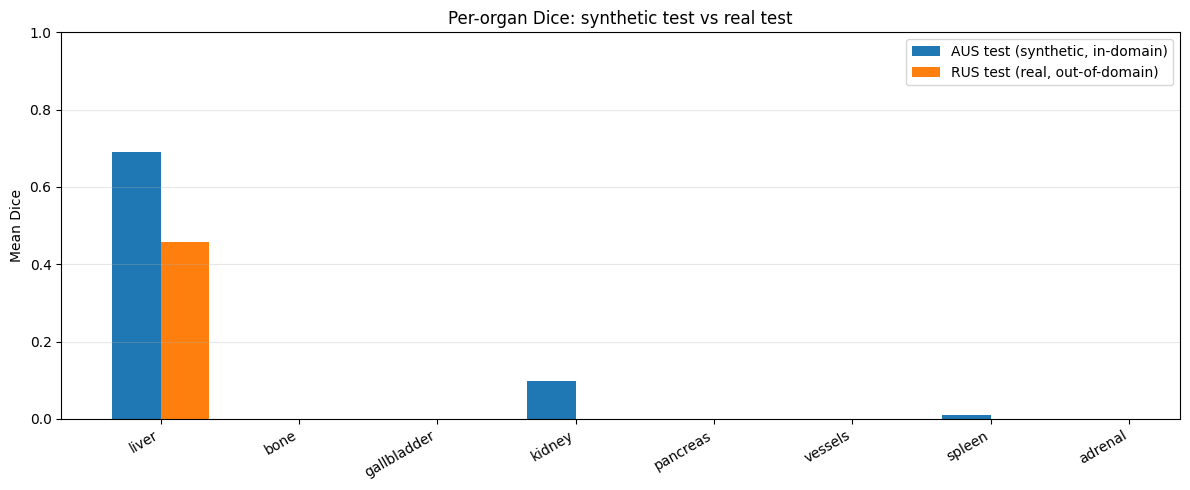

In [27]:
summary_plot = summary.copy()
summary_plot = summary_plot.reset_index().rename(columns={"index": "organ"})

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(summary_plot))
width = 0.35
ax.bar(x - width/2, summary_plot.iloc[:, 1], width,
       label=summary_plot.columns[1], color="tab:blue")
ax.bar(x + width/2, summary_plot.iloc[:, 2], width,
       label=summary_plot.columns[2], color="tab:orange")
ax.set_xticks(x); ax.set_xticklabels(summary_plot["organ"], rotation=30, ha="right")
ax.set_ylabel("Mean Dice"); ax.set_ylim(0, 1)
ax.set_title("Per-organ Dice: synthetic test vs real test")
ax.legend(); ax.grid(alpha=0.3, axis="y") 
plt.savefig("/kaggle/working/v1_per_organ_dice.png", dpi=120, bbox_inches="tight")
plt.tight_layout(); plt.show()


## 11. Inference visualization

**What this section does:** Shows qualitative predictions side by side with ground truth for a few samples from each test set.

**Why qualitative checks matter:** Numbers can hide important failure modes. A model with 0.5 Dice on liver might be predicting good liver shape in the right location, OR it might be predicting noisy fragmented blobs everywhere, same number, very different model. Eyes catch what metrics miss.

Loading dataset: 100%|██████████| 3/3 [00:00<00:00, 10.02it/s]


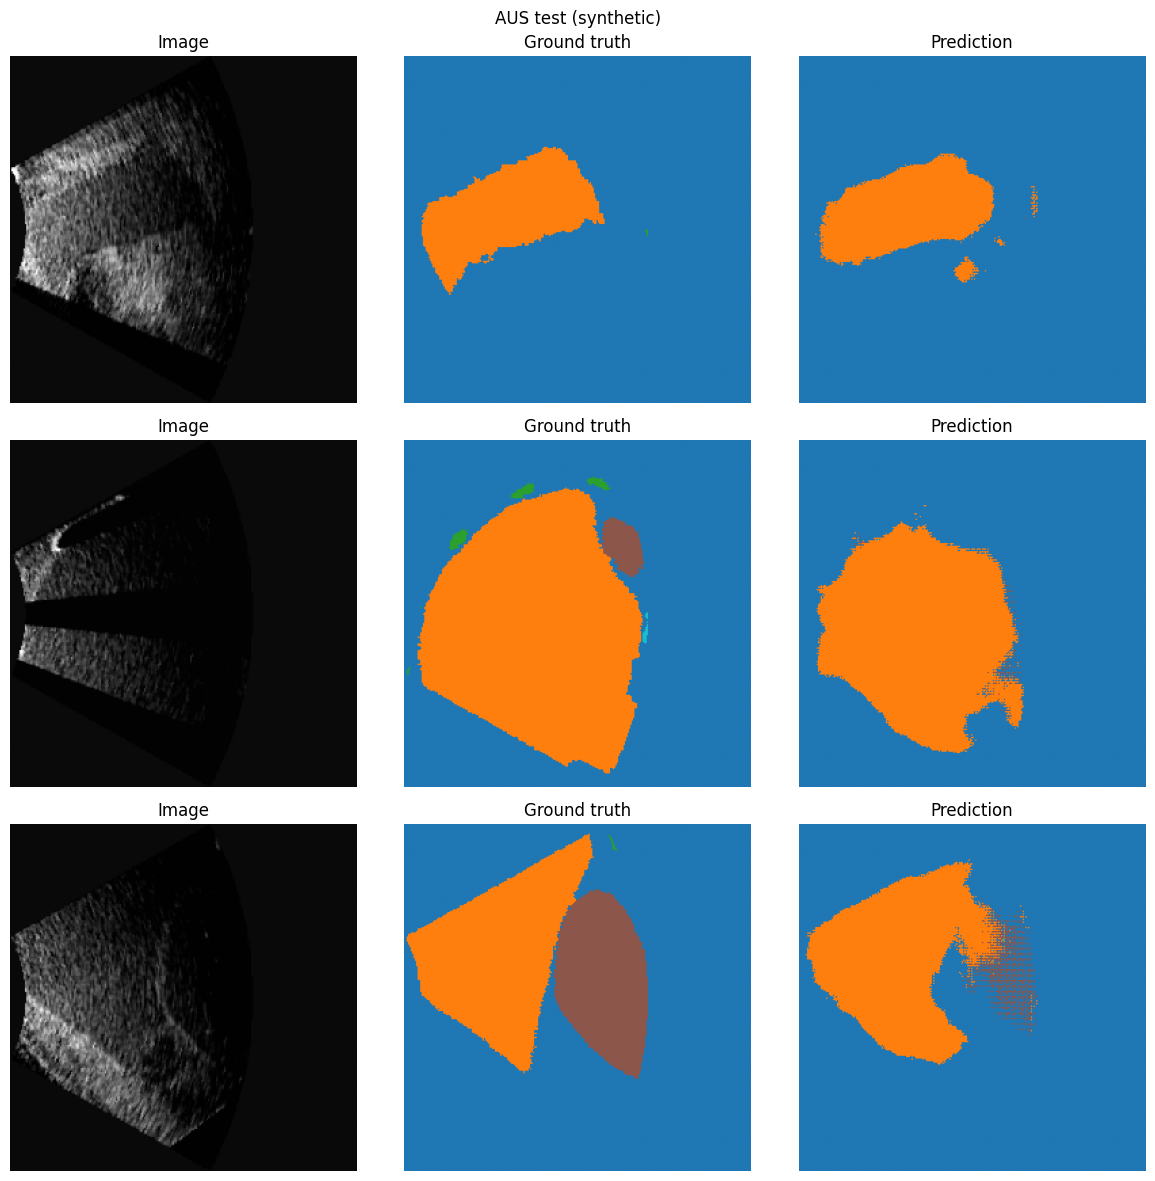

Loading dataset: 100%|██████████| 3/3 [00:00<00:00,  7.69it/s]


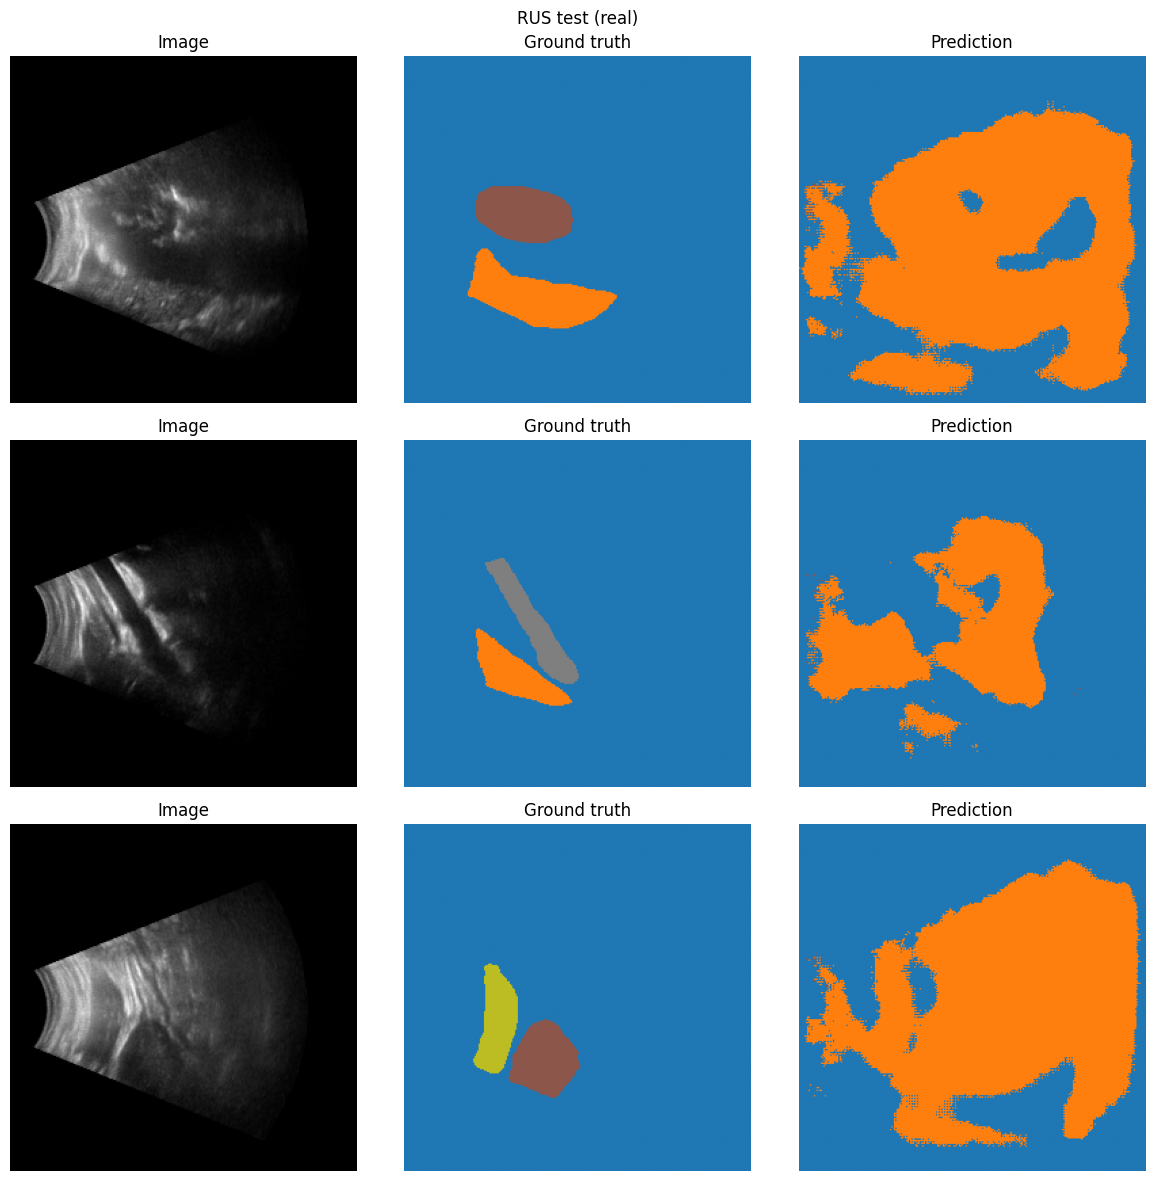

In [24]:
def visualize_predictions(files: list[dict], title: str, n: int = 3):
    if len(files) == 0:
        return
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()

    ds = CacheDataset(data=files[:n], transform=val_transforms,
                      cache_num=n, num_workers=0)
    loader = DataLoader(ds, batch_size=1, shuffle=False)

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = axes[None, :]
    with torch.no_grad():
        for i, batch in enumerate(loader):
            image = batch["image"].to(device)
            label = batch["label"]
            with autocast("cuda", enabled=scaler.is_enabled()):
                logits = model(image)
            pred = torch.softmax(logits, dim=1).argmax(dim=1)

            axes[i, 0].imshow(image[0, 0].cpu(), cmap="gray")
            axes[i, 0].set_title("Image"); axes[i, 0].axis("off")
            axes[i, 1].imshow(label[0, 0], cmap="tab10", vmin=0, vmax=NUM_CLASSES-1)
            axes[i, 1].set_title("Ground truth"); axes[i, 1].axis("off")
            axes[i, 2].imshow(pred[0].cpu(), cmap="tab10", vmin=0, vmax=NUM_CLASSES-1)
            axes[i, 2].set_title("Prediction"); axes[i, 2].axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()


visualize_predictions(test_aus_files, "AUS test (synthetic)", n=3)
visualize_predictions(test_rus_files, "RUS test (real)", n=3)


## 12. What we learned (V1)

**Headline observation: mode collapse.**

If you ran this notebook with `TUTORIAL_MODE=False` for full training, you likely observed something like:

| Class | AUS test Dice | RUS test Dice |
|---|---|---|
| **liver** | **~0.69** | **~0.46** |
| bone | 0.000 | NaN |
| gallbladder | 0.000 | 0.000 |
| kidney | ~0.09 | 0.000 |
| pancreas | 0.000 | NaN |
| vessels | 0.000 | 0.000 |
| spleen | ~0.01 | 0.000 |
| adrenal | 0.000 | NaN |
| **Mean** | **~0.087** | — |

*(Exact numbers vary slightly between runs due to random initialization and augmentation. NaN indicates classes that don't appear in any RUS test image.)*

**What's happening:** The model successfully learned liver — a meaningful result by itself. But every other organ has Dice near zero. The model has *collapsed* onto predicting "liver" everywhere there's organ-like signal in the image.

**Why mode collapse happens:** Liver is the largest, most common organ in abdominal scans. Its pixels dominate the gradient signal during training. Without intervention, the optimizer finds a local optimum of "predict liver everywhere" and stops exploring other classes.

**Validation Dice plateau:** Did you notice the validation mean Dice plateaued near 0.085 from epoch 3 onwards while training loss kept decreasing? That's the smoking gun: liver Dice was improving (0.4 → 0.7 over training), but mean = (liver_dice + 7 zeros) / 8 ≈ 0.085 regardless. The model was learning, but only on one class.

## 13. The fix is in the V2 notebook

The companion notebook [`abdomen_us_v2_class_weighted.ipynb`](./abdomen_us_v2_class_weighted.ipynb) addresses mode collapse by adding a `weight` argument to `DiceCELoss`. The change is small (one tensor) but the impact is large (mean Dice triples, five organs recover from 0.0 to meaningful scores).

Open V2 next to see how a one-line config change addresses class imbalance, and to see the side-by-side comparison.

## 14. Going further

- **3D context:** Real abdominal ultrasound is video, not isolated frames. A 3D UNet over the temporal axis can exploit this.
- **Domain adaptation:** The dataset includes an `aus2rus/` folder with CycleGAN translation models. Translating synthetic to real-like before training is the natural next step for closing the synthetic-to-real gap.
- **MONAI bundles:** Once you have a working configuration, wrapping it as a MONAI bundle makes the model shareable.

## Citations

Vitale S, Orlando JI, Iarussi E, Larrabide I. *Improving realism in patient-specific abdominal ultrasound simulation using CycleGANs*. International Journal of Computer Assisted Radiology and Surgery 15(2):183–192, 2020.

## Acknowledgements

Dataset authors: Vitale et al., Pladema Institute, UNICEN, Argentina. Released under a Creative Commons license after winning a Kaggle Open Data Research Grant.

This tutorial is part of the [MONAI Ultrasound Working Group](https://github.com/Project-MONAI/wg-ultrasound) `data_and_tutorials` series.